# Career Compass SG — Exploratory Data Analysis

**Module 1 Group 7 · Singapore Jobs Analytics · Topic: Career Recommendations**

This notebook is the evidence behind the dashboard. It follows the order taught in
Lessons 1.8 (EDA Basic), 1.9 (EDA Advanced) and 1.10 (Data Visualisation & Storytelling):

| Part | Question | Lesson |
|---|---|---|
| 0 | Load a sample, not the whole file | 1.8 Getting Started |
| 1 | How big is this, and what is in it? | 1.8 Part 1 — Descriptive statistics |
| 2 | Can I trust it? | 1.8 Part 2 — Missing data, duplicates, impossible values |
| 3 | What should I build from it? | 1.8 Part 3 — Transformation & feature engineering |
| 4 | What is the pattern? | 1.9 — Grouping and aggregation |
| 5 | What is the message? | 1.10 — Charts that state a finding |

> **The one rule from Lesson 1.10 we followed throughout:**
> *the chart is chosen by the message, not by taste.* Every chart below has its
> finding written above it in words first.

## Setup

`src/` holds the production code. We import the **same functions the ETL uses**, so
anything demonstrated here is literally what ran over all 1,044,597 rows — the
notebook and the pipeline cannot drift apart.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
from features import add_features, clean_chunk, explode_categories, parse_categories

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110

RAW = config.RAW_CSV
PROC = config.PROCESSED_DIR
FIGS = config.FIGURES_DIR
FIGS.mkdir(parents=True, exist_ok=True)
print("Raw file:", RAW.name, f"({RAW.stat().st_size / 1e6:,.0f} MB)")

Raw file: SGJobData.csv (286 MB)


---
## Part 0 — Taste a spoonful before cooking the pot

The brief is explicit about this and it is good advice: the file is ~1M rows and
273 MB. Every decision below was designed on a 50,000-row sample and only then run
over the full file.

In [2]:
sample = pd.read_csv(RAW, nrows=config.SAMPLE_ROWS)

# The three first EDA moves from the brief
print("1. shape:", sample.shape)
print()
sample.info()

1. shape: (50000, 22)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   categories                          50000 non-null  str    
 1   employmentTypes                     50000 non-null  str    
 2   metadata_expiryDate                 50000 non-null  str    
 3   metadata_isPostedOnBehalf           50000 non-null  bool   
 4   metadata_jobPostId                  50000 non-null  str    
 5   metadata_newPostingDate             50000 non-null  str    
 6   metadata_originalPostingDate        50000 non-null  str    
 7   metadata_repostCount                50000 non-null  int64  
 8   metadata_totalNumberJobApplication  50000 non-null  int64  
 9   metadata_totalNumberOfView          50000 non-null  int64  
 10  minimumYearsExperience              50000 non-null  int64  
 11  numberOfVacancies            

In [3]:
# 3. Pick one numeric column — what is typical, and what is extreme?
sample["salary_minimum"].describe()

count     50000.000000
mean       3726.072200
std        2569.437218
min           1.000000
25%        2500.000000
50%        3000.000000
75%        4500.000000
max      180000.000000
Name: salary_minimum, dtype: float64

**First red flag, thirty seconds in.** The minimum monthly salary is **0** and the
maximum is **180,000**. Neither is a wage: one is "not disclosed" and the other is an
annual figure typed into a monthly field. We come back to this in Part 2.

---
## Part 1 — How big is this, and what is in it?

### 1.1 The five-move first look (Lesson 1.8 §1.1)

In [4]:
sample.head(3)

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,0,1,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,2,2,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,3,1,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0


In [5]:
# Move 4: just the types. `object` means text (or mixed).
sample.dtypes.value_counts()

str        11
int64       8
float64     2
bool        1
Name: count, dtype: int64

In [6]:
# Move 5: the numbers. Read the min and max rows first - that is where impossible
# values hide.
sample.describe().T[["count", "mean", "std", "min", "50%", "max"]].round(1)

,count,mean,std,min,50%,max
metadata_repostCount,50000.0,0.4,0.7,0.0,0.0,2.0
metadata_totalNumberJobApplication,50000.0,10.9,22.6,0.0,4.0,620.0
metadata_totalNumberOfView,50000.0,134.4,177.5,0.0,78.0,5653.0
minimumYearsExperience,50000.0,2.8,2.4,0.0,2.0,30.0
numberOfVacancies,50000.0,2.6,10.2,1.0,1.0,999.0
occupationId,0.0,NaN,NaN,NaN,NaN,NaN
salary_maximum,50000.0,5438.2,4047.1,1.0,4500.0,230000.0
salary_minimum,50000.0,3726.1,2569.4,1.0,3000.0,180000.0
status_id,50000.0,0.0,0.0,0.0,0.0,0.0
average_salary,50000.0,4582.2,3232.1,1.0,3750.0,205000.0


### 1.2 The categorical columns

`.value_counts()` on the text columns tells us what we are actually dealing with.

In [7]:
for col in ["employmentTypes", "positionLevels", "status_jobStatus", "salary_type"]:
    print(f"--- {col} ---")
    print(sample[col].value_counts().head(10))
    print()

--- employmentTypes ---
employmentTypes
Permanent                22591
Full Time                19068
Contract                  5859
Part Time                 1208
Temporary                  824
Internship/Attachment      310
Freelance                   96
Flexi-work                  44
Name: count, dtype: int64

--- positionLevels ---
positionLevels
Executive            12119
Junior Executive      8546
Non-executive         6415
Senior Executive      5457
Fresh/entry level     5316
Manager               5164
Professional          4801
Middle Management     1179
Senior Management     1003
Name: count, dtype: int64

--- status_jobStatus ---
status_jobStatus
Closed     46867
Re-open     3133
Name: count, dtype: int64

--- salary_type ---
salary_type
Monthly    50000
Name: count, dtype: int64



Three things worth writing down:

1. **`salary_type` is 100% `Monthly`.** No currency or period conversion is needed —
   one less way to get the analysis wrong.
2. **`positionLevels` has 9 values.** Nine is too many for a person to reason about;
   we collapse them to 5 seniority bands in Part 3.
3. **`status_jobStatus` is dominated by one value.** Worth remembering when we later
   ask why so many postings have zero applications.

### 1.3 The `categories` column is not a category

This is the one column the brief warns about, and it is the reason the whole project
needs two tables instead of one.

In [8]:
print(sample["categories"].iloc[0])
print()
print("parsed ->", parse_categories(sample["categories"].iloc[0]))

[{"id":13,"category":"Environment / Health"},{"id":25,"category":"Manufacturing"},{"id":36,"category":"Sciences / Laboratory / R&D"}]

parsed -> ['Environment / Health', 'Manufacturing', 'Sciences / Laboratory / R&D']


In [9]:
cat_counts = sample["categories"].dropna().map(parse_categories)
print(f"A job belongs to {cat_counts.map(len).mean():.2f} categories on average")
print(f"Maximum categories on one job: {cat_counts.map(len).max()}")
print(f"Distinct categories in the sample: {len(set(c for lst in cat_counts for c in lst))}")

A job belongs to 1.67 categories on average
Maximum categories on one job: 5
Distinct categories in the sample: 43


> **Design consequence.** Counting rows answers *"how many postings are there"*.
> Counting rows **after exploding categories** answers *"how many IT jobs are there"*.
> They are different questions, so the pipeline produces two tables — a wide one
> (`jobs_clean.parquet`, one row per posting) and a long one
> (`jobs_by_category.parquet`, one row per posting × category). Category shares
> therefore overlap and do not sum to 100%, which we say on the dashboard.

---
## Part 2 — Can I trust it? (Lesson 1.8 Part 2)

### 2.1 Missing data

In [10]:
missing = (sample.isna().mean() * 100).round(2).sort_values(ascending=False)
missing[missing > 0]

occupationId    100.0
dtype: float64

Two very different kinds of missing:

* **`occupationId` — 100% empty.** Verified across all 1,048,585 rows, not just the
  sample. A column that is always empty cannot inform anything, so it is dropped.
* **Everything else — 0.14%.** Notice they are all *the same* 0.14%. That is the
  signature of broken export lines rather than of individually missing fields.

In [11]:
# Are the ~0.14% of gaps the same rows? If so we can drop whole rows, not columns.
broken = sample[sample["metadata_jobPostId"].isna()]
print(f"Rows with no job id: {len(broken)}")
print("Of those, how many are also missing title/company/dates?")
print(broken[["title", "postedCompany_name", "metadata_originalPostingDate"]].isna().sum())

Rows with no job id: 0
Of those, how many are also missing title/company/dates?
title                           0
postedCompany_name              0
metadata_originalPostingDate    0
dtype: int64


Confirmed: they are entirely empty rows. **Decision — drop the rows, keep the columns.**
Over the full file this removes 3,988 rows (0.38%).

### 2.2 Duplicates

The brief hints that the same job is re-posted, so we expected duplicate ids. We checked
rather than assumed.

In [12]:
ids = sample["metadata_jobPostId"]
print("duplicated() including blanks :", ids.duplicated().sum())
print("duplicated() excluding blanks :", ids.dropna().duplicated().sum())

duplicated() including blanks : 0
duplicated() excluding blanks : 0


> **A trap worth naming in the report.** `.duplicated()` counts repeated *blanks* as
> duplicates. The first number looks like a duplicate problem; the second shows there
> is none. Across the full file there are **zero** genuine duplicate job ids — the
> repeated-posting signal lives in `metadata_repostCount` instead, not in duplicate rows.
> We still de-duplicate defensively in the pipeline (`keep="last"`), it simply removes nothing.

### 2.3 Impossible values (Lesson 1.8 §2.3)

This is where most of the cleaning judgement sits, so each rule is stated with its reason.

In [13]:
s = sample
print(f"salary_minimum == 0        : {(s.salary_minimum == 0).sum():>6,}")
print(f"salary_minimum < 500 (>0)  : {((s.salary_minimum < 500) & (s.salary_minimum > 0)).sum():>6,}")
print(f"salary_maximum > 60,000    : {(s.salary_maximum > 60_000).sum():>6,}")
print(f"salary_minimum > maximum   : {(s.salary_minimum > s.salary_maximum).sum():>6,}")
print(f"minimumYearsExperience > 40: {(s.minimumYearsExperience > 40).sum():>6,}")

salary_minimum == 0        :      0
salary_minimum < 500 (>0)  :    371
salary_maximum > 60,000    :     14
salary_minimum > maximum   :      0
minimumYearsExperience > 40:      0


In [14]:
# What does a "180,000 per month" posting actually look like?
s.loc[s.salary_maximum > 60_000, ["title", "salary_minimum", "salary_maximum", "positionLevels"]].head(5)

,title,salary_minimum,salary_maximum,positionLevels
4234,3D DESIGNER,5000,80000,Manager
9932,Senior Software Engineer [Java/ Oracle/ Up to ...,8000,110000,Senior Executive
11600,Product Marketing Manager,57600,66000,Manager
11799,"Account Executive, Singapore & Malaysia",80000,110000,Senior Executive
11865,"Account Executive, Singapore & Malaysia (Junior)",75000,90000,Executive


**The four salary rules, and why each one is what it is:**

| Rule | What we do | Why not something else |
|---|---|---|
| `salary == 0` | set to missing | Zero is "not disclosed", not "this job pays nothing". Treating it as a number would drag every average down. |
| `min > max` | swap the two values | The fields were entered the wrong way round. The information is there; dropping the row would throw away a real posting. |
| `min < $500` or `max > $60,000` | blank the salary, **keep the row** | These are annual figures in a monthly field. We still want the posting to count as demand — we just cannot trust its pay. |
| top/bottom 1% | **cap**, do not delete | A thin tail of genuine executive packages drags the mean. Capping keeps the row (so demand counts stay right) while stopping ~19,600 rows from steering every average. |

The consistent principle: **blank the untrustworthy field, keep the trustworthy row.**
A posting with a broken salary still tells us a job exists.

In [15]:
# Run the real cleaning function on the sample and read its audit counters.
cleaned_sample, stats = clean_chunk(sample.copy())
pd.Series(stats)

rows_in                    50000
dropped_empty_rows             0
unparseable_dates              0
expiry_before_posting          0
salary_zero_to_na              0
salary_swapped                 0
salary_impossible_to_na      385
experience_capped              0
vacancies_fixed                2
rows_out                   50000
dtype: int64

### 2.4 The finding that changed the whole design

Every project has one moment where the data tells you something you did not ask.
Here it is. We plotted engagement (views, applications) over time purely as a sanity
check — and found the dataset is **two stitched extracts**.

In [16]:
probe = pd.read_csv(
    RAW,
    usecols=[
        "metadata_originalPostingDate",
        "metadata_totalNumberOfView",
        "metadata_totalNumberJobApplication",
    ],
)
probe["month"] = pd.to_datetime(probe["metadata_originalPostingDate"]).dt.to_period("M")

engagement = probe.groupby("month").agg(
    postings=("metadata_totalNumberOfView", "size"),
    mean_views=("metadata_totalNumberOfView", "mean"),
    zero_application_pct=("metadata_totalNumberJobApplication", lambda x: (x == 0).mean() * 100),
).round(1)
engagement

,postings,mean_views,zero_application_pct
month,,,
2022-10,172,248.9,11.6
2022-11,590,255.1,4.2
2022-12,1184,231.9,11.7
2023-01,2764,251.3,10.7
2023-02,5855,253.5,7.5
2023-03,19414,164.4,16.7
2023-04,33094,130.7,18.2
2023-05,70213,111.5,18.3
2023-06,70410,69.3,27.9


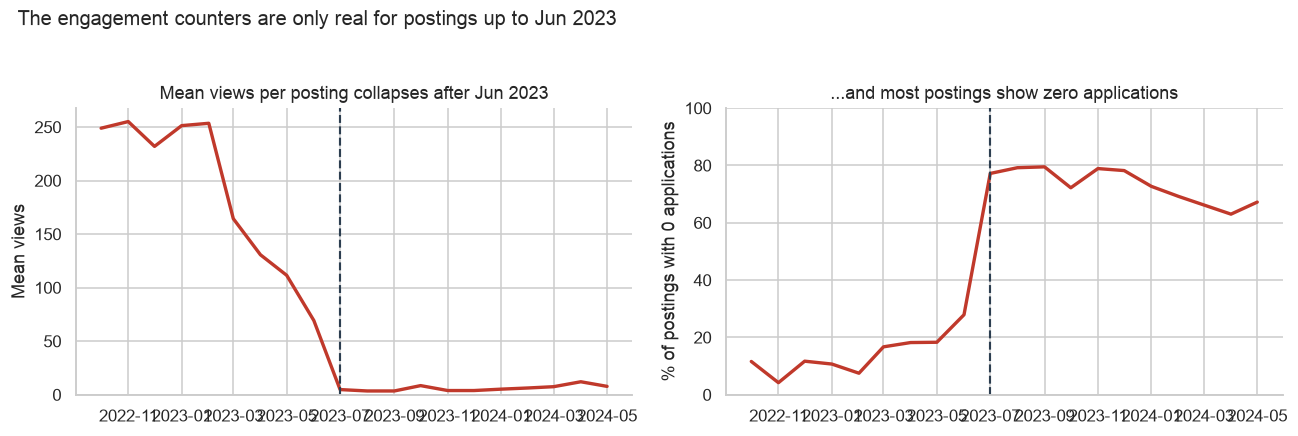

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
x = engagement.index.to_timestamp()
cut = pd.Timestamp("2023-07-01")

axes[0].plot(x, engagement["mean_views"], color="#c0392b", linewidth=2.2)
axes[0].axvline(cut, color="#2c3e50", linestyle="--", linewidth=1.4)
axes[0].set_title("Mean views per posting collapses after Jun 2023")
axes[0].set_ylabel("Mean views")
axes[0].set_ylim(0, None)

axes[1].plot(x, engagement["zero_application_pct"], color="#c0392b", linewidth=2.2)
axes[1].axvline(cut, color="#2c3e50", linestyle="--", linewidth=1.4)
axes[1].set_title("...and most postings show zero applications")
axes[1].set_ylabel("% of postings with 0 applications")
axes[1].set_ylim(0, 100)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=0)

fig.suptitle(
    "The engagement counters are only real for postings up to Jun 2023",
    fontsize=13, y=1.04, x=0.02, ha="left",
)
fig.tight_layout()
fig.savefig(FIGS / "eda_engagement_break.png", dpi=150, bbox_inches="tight")
plt.show()

> ### The single most important finding in this project
>
> Mean views per posting fall from **~111 to ~5** and the share of postings with zero
> applications jumps from **18% to 79%**, exactly at the Jun/Jul 2023 boundary.
>
> This is not a collapse in interest — it is a **collection artefact**. Postings from
> 2023-07 onward were captured at or near posting time, so their counters never
> accumulated.
>
> **What we did about it.** Demand and salary are trustworthy across the whole file and
> use all 1.04M rows. Competition (applications per vacancy) is computed **only** on
> postings up to 2023-06-30 — 203,702 of them — and is labelled as such everywhere it
> appears. Had we ignored this, every career track would have looked uncontested, and the
> recommender would have confidently pointed people at the most crowded markets in Singapore.

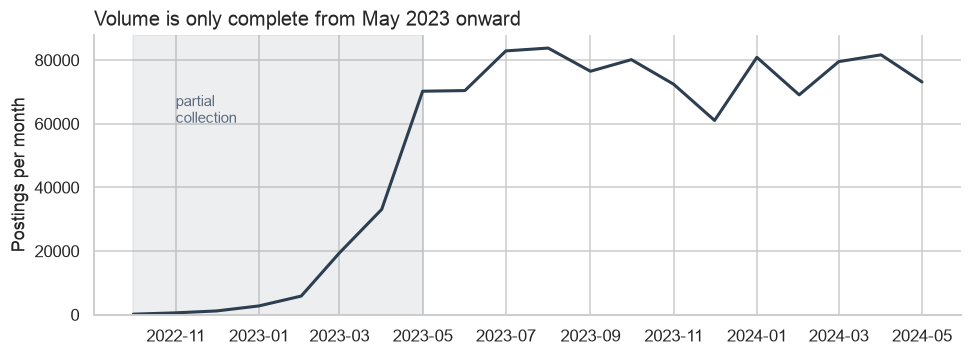

In [18]:
# The same check for posting VOLUME - a second, smaller artefact.
volume = probe.groupby("month").size()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(volume.index.to_timestamp(), volume.values, color="#2c3e50", linewidth=2)
ax.axvspan(
    volume.index.to_timestamp().min(), pd.Timestamp("2023-05-01"),
    color="#8c9196", alpha=0.15,
)
ax.text(pd.Timestamp("2022-11-01"), volume.max() * 0.72, "partial\ncollection",
        color="#5d6d7e", fontsize=10)
ax.set_ylim(0, None)
ax.set_ylabel("Postings per month")
ax.set_title("Volume is only complete from May 2023 onward", fontsize=13, loc="left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS / "eda_volume_ramp.png", dpi=150, bbox_inches="tight")
plt.show()

**Second design consequence.** Trend charts and all growth calculations start at
**May 2023**. A "growth" number that included the ramp would be measuring our data
collection, not Singapore's hiring.

---
## Part 3 — Feature engineering (Lesson 1.8 Part 3)

Raw columns describe a *posting*. A job seeker needs columns that describe an
*opportunity*. These are the features we added and the question each one answers.

| Feature | The question it answers |
|---|---|
| `seniority` | 9 official levels → 5 bands a person actually thinks in |
| `salary_band`, `experience_band` | "which bracket am I in?" |
| `applications_per_vacancy` | **"how many people am I up against for each seat?"** |
| `apply_rate` | of the people who saw it, how many acted? |
| `is_hard_to_fill` | the employer could not fill this — that is an opening |
| `is_entry_friendly` | can I apply today, with what I have? |
| `title_clean` | count *roles*, not adverts |
| `skill` (long table) | which terms in a title carry a pay premium |

In [19]:
featured = add_features(cleaned_sample)
featured[["title", "title_clean"]].dropna().head(8)

,title,title_clean
0,Food Technologist - Clementi | Entry Level | U...,Food Technologist - Clementi
1,"Software Engineer (Fab Support) (Java, CIM, Up...",Software Engineer - Ds
2,Senior Technician,Senior Technician
3,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",Senior .Net Developer - Ds
4,Sales / Admin Cordinator,Sales / Admin Cordinator
5,Software Support Engineer,Software Support Engineer
6,Urgent Hiring!!! Business Development Manager ...,Business Development Manager
7,IT Security Engineer (Maritime/ Cloud Security),It Security Engineer


**Why `title_clean` matters.** Singapore job titles carry a lot of marketing:
`"Urgent Hiring!!! Business Development Manager (MES, Pre-sales) - Up to $9K"`.
Counting raw titles counts *adverts*; counting cleaned titles counts *roles*.
Without this step the "most common job title" list is mostly noise.

In [20]:
print("Raw distinct titles     :", featured["title"].nunique())
print("Cleaned distinct titles :", featured["title_clean"].nunique())
print()
print("Top 8 roles after cleaning:")
print(featured["title_clean"].value_counts().head(8))

Raw distinct titles     : 30173
Cleaned distinct titles : 23437

Top 8 roles after cleaning:
title_clean
Sales Executive       320
Project Engineer      277
Project Manager       261
Quantity Surveyor     253
Accounts Executive    249
Driver                206
Supervisor            202
Admin Assistant       189
Name: count, dtype: int64[pyarrow]


---
## Part 4 — What is the pattern? (Lesson 1.9)

From here we switch from the sample to the **full cleaned dataset** produced by
`src/etl_clean.py`, because the questions now need every row.

In [21]:
jobs = pd.read_parquet(PROC / "jobs_clean.parquet")
by_cat = pd.read_parquet(PROC / "jobs_by_category.parquet")
categories = pd.read_parquet(PROC / "agg_category.parquet")
skills = pd.read_parquet(PROC / "agg_skill.parquet")
tracks = pd.read_parquet(PROC / "career_tracks.parquet")
quality = json.loads((PROC / "data_quality_report.json").read_text())

print(f"postings          : {len(jobs):,}")
print(f"job x category    : {len(by_cat):,}")
print(f"career tracks     : {len(tracks):,}")
print(f"rows read from CSV: {quality['rows_read']:,}")
print(f"rows kept         : {quality['rows_after_cleaning']:,} "
      f"({quality['rows_after_cleaning'] / quality['rows_read']:.2%})")

postings          : 1,044,597
job x category    : 1,767,829
career tracks     : 215
rows read from CSV: 1,048,585
rows kept         : 1,044,597 (99.62%)


In [22]:
# The market in one table
pd.Series({
    "Postings": f"{len(jobs):,}",
    "Vacancies (seats)": f"{int(jobs['vacancies'].sum()):,}",
    "Categories": jobs.shape[0] and by_cat["category"].nunique(),
    "Posting organisations": f"{jobs['company'].nunique():,}",
    "Median salary": f"${jobs['avg_salary'].median():,.0f}",
    "25th / 75th percentile": f"${jobs['avg_salary'].quantile(.25):,.0f} / ${jobs['avg_salary'].quantile(.75):,.0f}",
    "Salary disclosed": f"{jobs['avg_salary'].notna().mean():.1%}",
    "Entry-friendly (<=1 yr)": f"{jobs['is_entry_friendly'].mean():.1%}",
    "Reposted at least once": f"{jobs['is_hard_to_fill'].mean():.1%}",
}, name="value").to_frame()

,value
Postings,"1,044,597"
Vacancies (seats),"2,725,717"
Categories,43
Posting organisations,"53,150"
Median salary,"$3,850"
25th / 75th percentile,"$2,950 / $5,500"
Salary disclosed,99.0%
Entry-friendly (<=1 yr),36.2%
Reposted at least once,4.1%


In [23]:
# Salary by seniority - the ladder
jobs.groupby("seniority", observed=True)["avg_salary"].agg(
    postings="size", median="median", p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75)
).reindex(config.SENIORITY_ORDER).round(0)

,postings,median,p25,p75
seniority,,,,
Entry,250269,2675.0,2150.0,3500.0
Junior,167656,3150.0,2650.0,3750.0
Mid,365909,4000.0,3350.0,5750.0
Senior,100459,5000.0,4000.0,6500.0
Management,160304,6500.0,4750.0,9000.0


In [24]:
# The 10 largest categories, with everything a job seeker would ask
categories.head(10)[[
    "category", "postings", "median_salary", "apps_per_vacancy",
    "entry_friendly_share", "hard_to_fill_share", "growth_pct_6m",
]].round(1)

,category,postings,median_salary,apps_per_vacancy,entry_friendly_share,hard_to_fill_share,growth_pct_6m
0,Information Technology,140866,6500.0,4.8,19.8,4.0,-11.7
1,Engineering,136372,4250.0,3.7,26.1,6.0,-3.2
2,Admin / Secretarial,117854,2900.0,5.7,57.5,3.4,-4.0
3,Customer Service,111785,3100.0,2.4,58.0,4.6,-0.9
4,Others,106101,3500.0,3.3,47.8,5.6,-1.7
5,Sales / Retail,105067,3600.0,2.5,48.0,3.7,-2.2
6,Building and Construction,84034,4050.0,3.6,16.5,4.8,3.9
7,Accounting / Auditing / Taxation,78648,3650.0,5.2,32.2,3.4,-5.8
8,F&B,73731,3301.0,1.0,38.7,4.7,1.2
9,Logistics / Supply Chain,69193,3250.0,4.4,42.5,4.2,-1.9


### 4.1 Three patterns worth stating in words

**(a) Size and pay are almost unrelated.** Admin/Secretarial is the 3rd largest
category (117,854 postings) and one of the worst paid ($2,900). Information Technology
is the largest *and* the best paid ($6,500). "Where the jobs are" and "where the money
is" are genuinely different questions — which is precisely why the recommender scores
both instead of ranking on one.

**(b) Competition varies by an order of magnitude.** Personal Care / Beauty sees
**0.7 applicants per seat**; Social Services sees **11.3**. Two categories with the same
number of openings can offer wildly different odds, and nothing on a job board tells
you this.

**(c) Hard-to-fill means underpaid, not elite.** Reposted jobs pay a median of
**$3,700** against **$3,850** for jobs filled first time. It is a negotiation lever,
not a prestige signal.

In [25]:
print("Competition spread across sizeable categories (>= 5,000 postings):")
big = categories[categories.postings >= 5000]
print(big.nsmallest(5, "apps_per_vacancy")[["category", "postings", "median_salary", "apps_per_vacancy"]].round(2).to_string(index=False))
print("   ...")
print(big.nlargest(5, "apps_per_vacancy")[["category", "postings", "median_salary", "apps_per_vacancy"]].round(2).to_string(index=False))
print()
print("Median salary, reposted vs filled first time:")
print(jobs.groupby("is_hard_to_fill")["avg_salary"].agg(postings="size", median="median"))

Competition spread across sizeable categories (>= 5,000 postings):
                  category  postings  median_salary  apps_per_vacancy
    Personal Care / Beauty     16932         4000.0              0.73
                       F&B     73731         3301.0              1.03
        Telecommunications      7964         4200.0              1.15
Security and Investigation      5461         2950.0              1.69
    Education and Training     44877         3300.0              2.02
   ...
                         category  postings  median_salary  apps_per_vacancy
                  Social Services      8684         3500.0             11.33
                  Risk Management      9390         6000.0              8.73
              Advertising / Media     19584         3500.0              8.51
     Marketing / Public Relations     53442         3750.0              8.07
Real Estate / Property Management     10513         4000.0              7.96

Median salary, reposted vs filled first tim

---
## Part 5 — What is the message? (Lesson 1.10)

Four charts. Each one has its finding written above it as a sentence, then the chart
is built to deliver that sentence — colour used as an argument, everything else grey.

### Chart 1 — Where the jobs are is not where the money is

*Message: the biggest categories are not the best-paying ones, with one exception.*

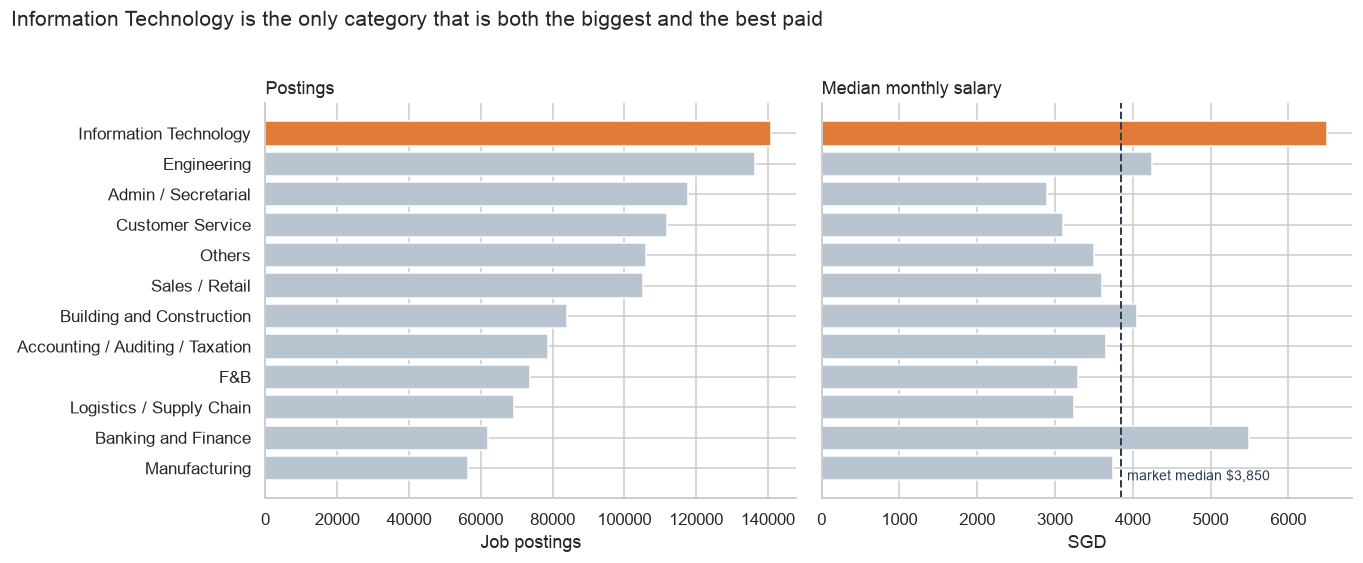

In [26]:
top = categories.head(12).sort_values("postings")
market_median = jobs["avg_salary"].median()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)

# Left: volume. One orange bar carries the point; the rest are context.
colours = ["#e07b39" if c == "Information Technology" else "#b8c4d0" for c in top["category"]]
axes[0].barh(top["category"], top["postings"], color=colours)
axes[0].set_title("Postings", fontsize=12, loc="left")
axes[0].set_xlabel("Job postings")

# Right: pay, same row order, same highlight.
axes[1].barh(top["category"], top["median_salary"], color=colours)
axes[1].axvline(market_median, color="#2c3e50", linestyle="--", linewidth=1.3)
axes[1].text(market_median * 1.02, -0.4, f"market median ${market_median:,.0f}",
             color="#2c3e50", fontsize=9)
axes[1].set_title("Median monthly salary", fontsize=12, loc="left")
axes[1].set_xlabel("SGD")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Information Technology is the only category that is both the biggest and the best paid",
    fontsize=13.5, x=0.01, ha="left", y=1.02,
)
fig.tight_layout()
fig.savefig(FIGS / "eda_volume_vs_pay.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 — What an average hides

*Message: the salary distribution is right-skewed, so the mean describes almost nobody.*
This is the Lesson 1.10 §3.1 lesson applied to our own data.

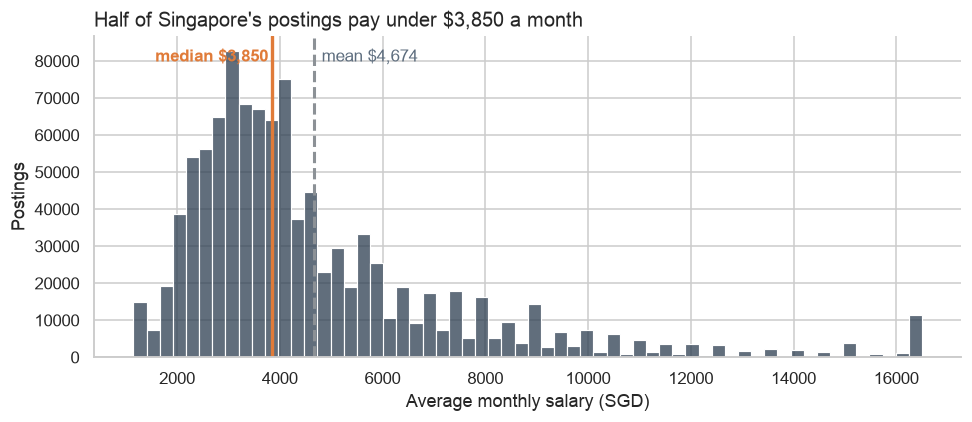

skew: 1.95  |  mean - median = $824


In [27]:
salaries = jobs["avg_salary"].dropna()
mean_v, median_v = salaries.mean(), salaries.median()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(salaries, bins=60, color="#2c3e50", ax=ax)
ax.axvline(median_v, color="#e07b39", linewidth=2.2)
ax.axvline(mean_v, color="#8c9196", linewidth=2, linestyle="--")
ax.text(median_v * 0.98, ax.get_ylim()[1] * 0.92, f"median ${median_v:,.0f}",
        color="#e07b39", ha="right", fontsize=11, fontweight="bold")
ax.text(mean_v * 1.03, ax.get_ylim()[1] * 0.92, f"mean ${mean_v:,.0f}",
        color="#5d6d7e", fontsize=11)
ax.set_xlabel("Average monthly salary (SGD)")
ax.set_ylabel("Postings")
ax.set_title(
    f"Half of Singapore's postings pay under ${median_v:,.0f} a month",
    fontsize=13, loc="left",
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS / "eda_salary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"skew: {salaries.skew():.2f}  |  mean - median = ${mean_v - median_v:,.0f}")

### Chart 3 — The opportunity map

*Message: volume alone is a bad guide; the categories worth targeting are the ones with
volume AND low competition.* This chart is the analytical core of the dashboard's
Demand vs Competition page.

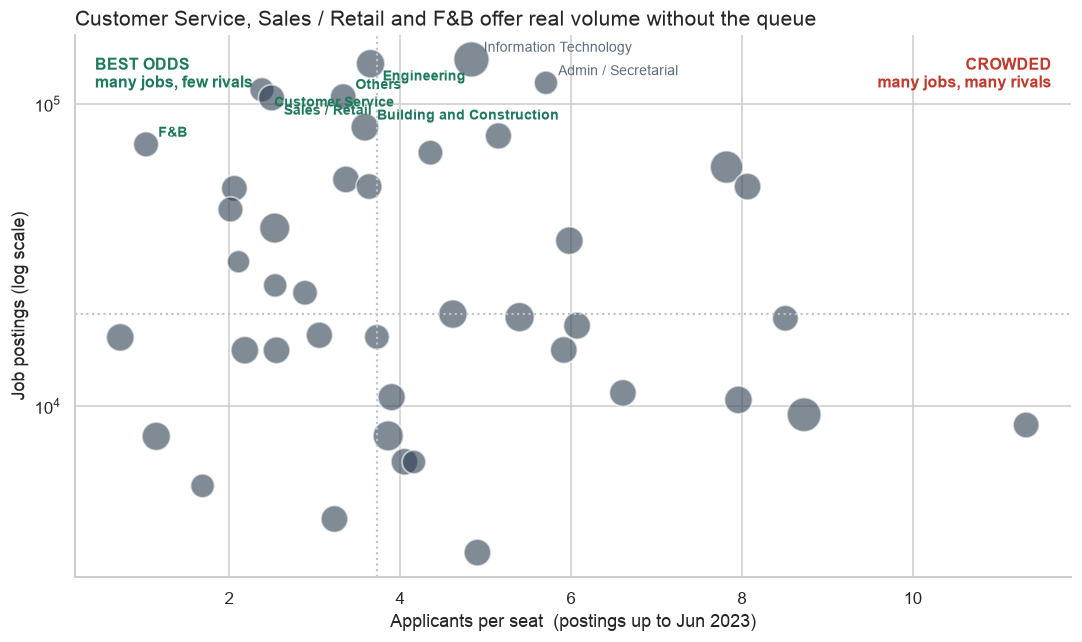

In [28]:
plot = categories[(categories.postings >= 2000) & categories.apps_per_vacancy.notna()]
x_split = plot["apps_per_vacancy"].median()
y_split = plot["postings"].median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    plot["apps_per_vacancy"], plot["postings"],
    s=plot["median_salary"] / 12, alpha=0.6,
    color="#2c3e50", edgecolor="white", linewidth=1.2,
)
ax.axvline(x_split, color="#b8c4d0", linestyle=":", linewidth=1.4)
ax.axhline(y_split, color="#b8c4d0", linestyle=":", linewidth=1.4)
ax.set_yscale("log")

# Label sparingly: the 6 biggest categories in the best-odds quadrant carry the
# message, plus the 3 biggest overall for orientation. Labelling every point
# produced unreadable collisions.
best_odds = plot[(plot.postings > y_split) & (plot.apps_per_vacancy < x_split)]
to_label = set(best_odds.nlargest(6, "postings")["category"])
context = set(plot.nlargest(3, "postings")["category"]) - to_label

for i, (_, r) in enumerate(plot.iterrows()):
    if r["category"] in to_label:
        colour, weight = "#1e7a5f", "bold"
    elif r["category"] in context:
        colour, weight = "#5d6d7e", "normal"
    else:
        continue
    offset = (8, 5) if i % 2 == 0 else (8, -11)
    ax.annotate(r["category"], (r["apps_per_vacancy"], r["postings"]),
                textcoords="offset points", xytext=offset,
                fontsize=9, color=colour, fontweight=weight)

ax.text(0.02, 0.96, "BEST ODDS\nmany jobs, few rivals", transform=ax.transAxes,
        color="#1e7a5f", fontsize=10.5, va="top", fontweight="bold")
ax.text(0.98, 0.96, "CROWDED\nmany jobs, many rivals", transform=ax.transAxes,
        color="#c0392b", fontsize=10.5, va="top", ha="right", fontweight="bold")

ax.set_xlabel("Applicants per seat  (postings up to Jun 2023)")
ax.set_ylabel("Job postings (log scale)")
ax.set_title(
    "Customer Service, Sales / Retail and F&B offer real volume without the queue",
    fontsize=13.5, loc="left",
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS / "eda_opportunity_map.png", dpi=150, bbox_inches="tight")
plt.show()

> **Why the y-axis is logarithmic.** Category sizes span two orders of magnitude
> (517 to 140,866 postings). On a linear axis the smaller half of the market collapses
> onto the floor and becomes unreadable. A log axis is the honest choice here — and we
> label it as such, because an unlabelled log axis is one of the easiest ways to mislead.

### Chart 4 — What skills are worth

*Message: the pay gap between the best- and worst-paying title keywords is a factor of
four, and it is the clearest investment signal in the dataset.*

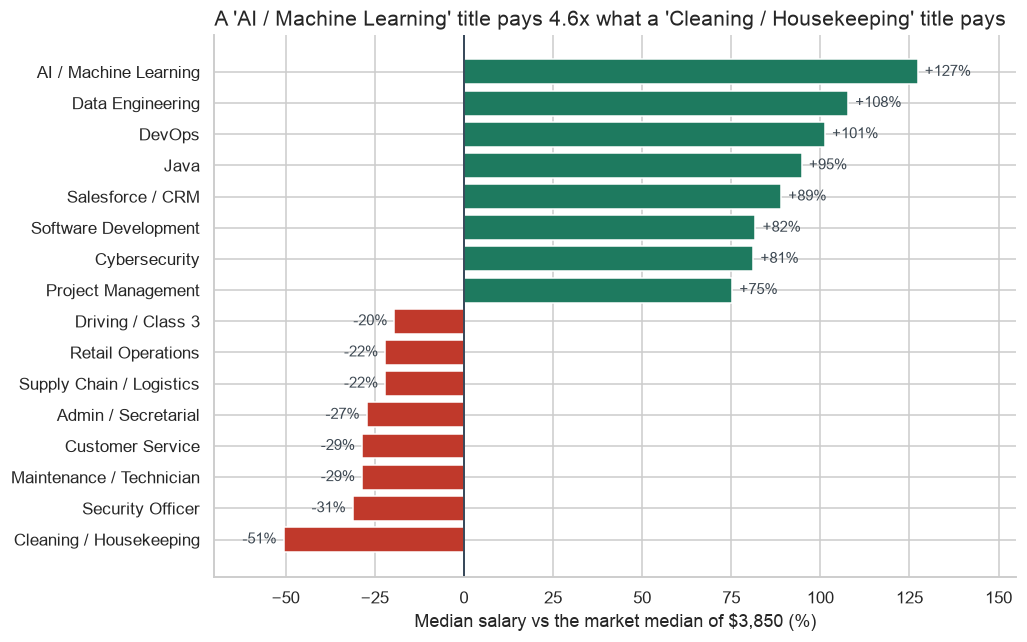

In [29]:
ranked = skills[skills.postings >= 1500].sort_values("salary_premium_pct")
ends = pd.concat([ranked.head(8), ranked.tail(8)])
colours = ["#c0392b" if v < 0 else "#1e7a5f" for v in ends["salary_premium_pct"]]

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.barh(ends["skill"], ends["salary_premium_pct"], color=colours)
ax.axvline(0, color="#2c3e50", linewidth=1.2)
for y, (v, n) in enumerate(zip(ends["salary_premium_pct"], ends["postings"])):
    ax.text(v + (2 if v > 0 else -2), y, f"{v:+.0f}%",
            va="center", ha="left" if v > 0 else "right", fontsize=9.5, color="#3d4852")
ax.set_xlabel(f"Median salary vs the market median of ${jobs['avg_salary'].median():,.0f} (%)")
ax.set_xlim(-70, 155)

best, worst = ends.iloc[-1], ends.iloc[0]
ratio = best["median_salary"] / worst["median_salary"]
ax.set_title(
    f"A '{best['skill']}' title pays {ratio:.1f}x what a '{worst['skill']}' title pays",
    fontsize=13.5, loc="left",
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS / "eda_skill_premium.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Part 6 — From analysis to product: the Career Fit Score

The four things a job seeker needs to weigh are measured in four different units —
counts, dollars, a ratio and a percentage. To combine them we convert each to a
**percentile rank (0–100)** across all 215 career tracks, then take a weighted average.
The weights are sliders in the dashboard, not constants in the code.

In [30]:
tracks.head(10)[[
    "track", "postings", "median_salary", "apps_per_vacancy",
    "demand_score", "pay_score", "low_competition_score",
    "accessibility_score_default", "fit_score_default",
]].round(1)

,track,postings,median_salary,apps_per_vacancy,demand_score,pay_score,low_competition_score,accessibility_score_default,fit_score_default
0,Information Technology - Mid,72757,6500.0,4.0,100.0,91.6,54.4,27.4,75.2
1,Information Technology - Senior,22564,7000.0,3.9,91.2,95.1,57.2,14.9,72.4
2,Sales / Retail - Junior,18967,3250.0,1.7,88.4,31.9,87.9,91.6,71.8
3,Healthcare / Pharmaceutical - Mid,17715,4000.0,2.0,87.0,55.8,82.3,54.4,71.6
4,Sales / Retail - Entry,29476,3000.0,1.2,97.2,19.1,93.0,87.0,71.2
5,Consulting - Mid,14360,4750.0,2.2,79.5,71.2,80.9,36.7,70.9
6,F&B - Mid,20421,3850.0,0.8,89.8,50.0,96.3,26.5,70.0
7,Consulting - Senior,5522,5250.0,0.8,56.7,80.2,95.3,29.8,69.4
8,Engineering - Senior,20066,5500.0,3.8,89.3,82.6,59.5,18.1,69.2
9,Engineering - Mid,51983,4250.0,3.9,99.5,60.9,56.7,41.4,68.5


**Reading the top of the table.** *Information Technology – Mid* wins on demand and pay
and merely average competition. *Sales / Retail – Junior* wins the opposite way: modest
pay, but 98% of its postings are open to someone with 3 years of experience and only
1.7 applicants per seat. **These are genuinely different recommendations for genuinely
different people** — which is why the score is user-weighted rather than fixed.

In [31]:
# Sensitivity check: does the ranking actually respond to the weights?
def rank_with(weights):
    w = np.array(weights, dtype=float)
    w = w / w.sum()
    cols = tracks[["demand_score", "pay_score", "low_competition_score",
                   "accessibility_score_default"]].fillna(50).to_numpy()
    scored = tracks.assign(score=cols @ w)
    return scored.nlargest(5, "score")["track"].tolist()

comparison = pd.DataFrame({
    "Balanced (default)": rank_with([30, 30, 25, 15]),
    "Money first": rank_with([10, 70, 10, 10]),
    "Easiest to enter": rank_with([15, 5, 30, 50]),
})
comparison.index = [f"#{i + 1}" for i in range(5)]
comparison

,Balanced (default),Money first,Easiest to enter
#1,Information Technology - Mid,Information Technology - Senior,Human Resources - Entry
#2,Information Technology - Senior,Information Technology - Mid,Sales / Retail - Junior
#3,Sales / Retail - Junior,Information Technology - Management,Sales / Retail - Entry
#4,Healthcare / Pharmaceutical - Mid,Banking and Finance - Management,Education and Training - Entry
#5,Sales / Retail - Entry,Engineering - Management,Events / Promotions - Entry


Swapping the weights genuinely swaps the advice. *Money first* keeps the IT tracks but
reorders them and pulls in Banking Management; *Easiest to enter* shares **no entries at
all** with the default — it surfaces HR, Sales and Education entry roles instead. The
score responds to what the user says they care about rather than dressing up one fixed
ranking.

---
## Summary — what the EDA decided

| Finding | What it changed in the product |
|---|---|
| `occupationId` 100% null; 3,988 wholly empty rows | dropped column, dropped rows |
| 10,000 impossible salaries; 19,647 extreme values | blank the field / cap at 1st–99th percentile, never delete the posting |
| Zero genuine duplicate job ids | de-duplication kept as a safeguard, documented as a no-op |
| A job carries 1.69 categories | two tables; category shares overlap and we say so |
| **Engagement counters die after Jun 2023** | **all competition metrics restricted to Oct 2022 – Jun 2023 and labelled** |
| Volume ramp before May 2023 | trend and growth views start May 2023 |
| Size ≠ pay ≠ low competition | the recommender scores four dimensions instead of ranking on one |
| Reposted jobs pay *less* | "hard to fill" framed as negotiation leverage, not prestige |
| Top posters are recruitment agencies | labelled "poster", never "employer" |

**Next:** `app/Home.py` — the dashboard built on these decisions.